# Intervention Experiments on OthelloGPT

This notebook tests **four problems with Li/Nanda's top-N intervention metric**
by running probe-directed interventions on OthelloGPT and comparing several
richer measurements against the standard top-N.

The four problems we address:

1. **Top-N ignores probability magnitudes.** It only counts whether each
   counterfactual-legal move is in the top-K — not by how much the model
   actually moved its probability mass.
2. **Top-N doesn't separate intervention conditions.** Different types of
   board edits (adding pieces, removing pieces, flipping colors) and
   different effects on legality (newly-legal, newly-illegal, both) all get
   collapsed into one number.
3. **Top-N ignores interference.** Each intervention also perturbs the model's
   internal representations of *other* cells, an effect that varies enormously
   by target square.
4. **Top-N looks at one intervention at a time.** It tells us nothing about
   how the model handles multiple simultaneous edits.

All outputs (tables and figures) land in `Intervention Results/` with
descriptive filenames.

## Section: Preliminaries

Imports, then load the modules in `src/` that contain all the experiment
logic. The notebook itself stays thin — every nontrivial function lives in
`src/` so we can reuse it across cells and easily reload after edits.

In [1]:
# Cell 1 — imports
# IMPORTANT: load %matplotlib inline BEFORE importing pyplot. Without this,
# matplotlib may try to launch the macOS GUI backend through the Jupyter
# kernel and hang.
%matplotlib inline

import sys, os, pickle, math, json
import numpy as np
import torch
import matplotlib.pyplot as plt

# Repo root needed so we can `from src import ...`
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# Pretty-print options
np.set_printoptions(precision=4, suppress=True)
torch.set_printoptions(precision=4, sci_mode=False)

### What's in `src/`

| Module | Responsibility |
|---|---|
| `config.py` | Default parameter values, paths, board constants, condition taxonomy. |
| `data.py` | Game replay, legal-move computation, sampling positions per condition. Defines the `PositionRecord` dataclass. |
| `probes.py` | Probe loading, probe-direction extraction (empty / flip / between-class), board decoding from a residual. |
| `intervention.py` | Model loading, partial forward passes, per-cell binary-search calibration, applying interventions. |
| `metrics.py` | Li top-N, all 6 mass-shift metrics, redistribution metric, log-prob distance distributions, crosstalk count. |
| `io.py` | `Intervention Results/` folder, ASCII-table saving via `tabulate`, database pickle save/load. |

`config.py` exposes defaults like `DEFAULT_INTERVENTION_LAYER=4`,
`DEFAULT_CAL_DEPTH=0`, `DEFAULT_CALIBRATION_MODE='fixed'`,
`DEFAULT_ALPHA=2.0`, `DEFAULT_PROBE_MODE=0`, plus paths to the model,
probe, and game files. **Nothing else hardcodes these values** — every
function takes them as arguments.

In [2]:
# Cell 2 — src imports
from src import config, data, probes, intervention, metrics
from src import io as iox

print("Output dir:", iox.ensure_output_dir())
print("Categories:", config.CATEGORIES)
print("Sub-conditions:", config.SUB_CONDITIONS)
print(f"Default intervention layer: {config.DEFAULT_INTERVENTION_LAYER}")
print(f"Default cal_depth: {config.DEFAULT_CAL_DEPTH}")
print(f"Default calibration_mode: {config.DEFAULT_CALIBRATION_MODE}")
print(f"Default alpha: {config.DEFAULT_ALPHA}")
print(f"Default probe_mode: {config.DEFAULT_PROBE_MODE} (mine/yours/empty)")

Output dir: /Users/jmorriso/Git/othello_world/Intervention Results
Categories: ['remove', 'add_mine', 'add_yours', 'flip']
Sub-conditions: ['newly_legal', 'newly_illegal', 'both']
Default intervention layer: 4
Default cal_depth: 0
Default calibration_mode: fixed
Default alpha: 2.0
Default probe_mode: 0 (mine/yours/empty)


### Experiment parameters

This is the **only place** we set the knobs for an experimental run. Change
these values and re-run downstream cells to sweep configurations.

- `intervention_layer`: which mingpt block's residual we modify (default L4).
- `cal_depth`: blocks of propagation between the intervention and the probe.
  cd=0 means intervene + decode at the same layer; cd=2 was Nanda's published
  setup; the probe layer is computed as `intervention_layer + cal_depth`.
- `calibration_mode`:
   - `"fixed"`: use a single global `alpha` for every position (Nanda's protocol).
   - `"per_square"`: binary-search a single alpha per target square, reused
     across all positions on that square.
   - `"per_position"`: binary-search alpha for every (square, position) pair.
- `alpha`: only used when `calibration_mode == "fixed"`. Otherwise serves as
  an upper-bound multiplier on the calibrated alpha.
- `probe_mode`: 0 = mine/yours/empty (best, ~99% probe acc). Mode 2 is the
  degraded absolute-color convention used by `sweep_intervention_alpha.py`.
- `n_positions_per_condition`: target sample size per (square, condition).
- `max_games`: stop searching after this many games even if we haven't filled
  every bucket.

In [3]:
# Cell 3 — params dict
params = config.assemble_params(
    intervention_layer = 4,
    cal_depth          = 0,           # default: same-layer, no propagation
    calibration_mode   = 'fixed',     # 'fixed' | 'per_square' | 'per_position'
    alpha              = 2.0,
    probe_mode         = 0,
    n_positions_per_condition = 1000,
    max_games          = 10_000,
    pos_lo             = 10,
    pos_hi             = 50,
    seed               = 42,
)
print(json.dumps({k: v for k, v in params.items()}, indent=2))
print(f"\n=> intervention at block {params['intervention_layer']}, "
      f"probe at block {params['probe_layer']}")

{
  "intervention_layer": 4,
  "cal_depth": 0,
  "calibration_mode": "fixed",
  "alpha": 2.0,
  "probe_mode": 0,
  "n_positions_per_condition": 1000,
  "max_games": 10000,
  "pos_lo": 10,
  "pos_hi": 50,
  "seed": 42,
  "probe_layer": 4
}

=> intervention at block 4, probe at block 4


### Load model, probe, games

The model is the Nanda-format mingpt OthelloGPT
(`ckpts/gpt_nanda_synthetic.ckpt`). The probe is Nanda's published linear
probe (`mechanistic_interpretability/main_linear_probe.pth`), shape
`(3 modes, 512, 8, 8, 3)`. Games come from the local 100k synthetic
dataset.

In [4]:
# Cell 4 — load
DEVICE = 'mps' if torch.backends.mps.is_available() else (
        'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

model = intervention.load_model(device=DEVICE)
probe = probes.load_probe(device=DEVICE)
board_seqs_int, board_seqs_string = data.load_games()
print(f"  model ready; probe shape {tuple(probe.shape)}; "
      f"{len(board_seqs_int)} games loaded")

Device: mps
  model ready; probe shape (3, 512, 8, 8, 3); 100000 games loaded


## Section: Create Database

For each target square × intervention category × sub-condition, sample up to
`n_positions_per_condition` positions from up to `max_games` games. Every
position is recorded with its move history (the canonical key for
reproducibility) plus the board state, the legality sets before and after
the counterfactual edit, and metadata.

**Intervention categories (4):**
- `remove`: occupied cell → empty.
- `add_mine`: empty cell → current player's color (next-to-move).
- `add_yours`: empty cell → opponent's color.
- `flip`: occupied cell → opposite color.

**Sub-conditions (3):** classify the change in the legality set:
- `newly_legal`: ≥1 move becomes legal, **no** moves become illegal.
- `newly_illegal`: ≥1 move becomes illegal, **no** moves become legal.
- `both`: at least one of each.

So we have 4 × 3 = **12 conditions per square**.

> **Note on board-center cells.** Cells (3,3), (3,4), (4,3), (4,4) are
> *never empty* in any game — they're starting positions. So when one of them
> is a target square, the `add_mine` and `add_yours` buckets will be empty.
> The bucket-counts table will show this; downstream cells skip empty
> buckets gracefully.

In [5]:
# Cell 5 — target squares
squares = [
    (3, 3),   # board-center starting cell
    (0, 3),   # edge
    (2, 3),   # intermediate
]
print(f"{len(squares)} target squares: {squares}")

3 target squares: [(3, 3), (0, 3), (2, 3)]


In [6]:
# Cell 6 — conditions
print("Categories:")
for cat in config.CATEGORIES:
    print(f"  {cat}")
print("\nSub-conditions:")
for sub in config.SUB_CONDITIONS:
    print(f"  {sub}")
print(f"\nTotal conditions per square: {len(config.CATEGORIES) * len(config.SUB_CONDITIONS)}")
print(f"Total conditions across {len(squares)} squares: "
      f"{len(squares) * len(config.CATEGORIES) * len(config.SUB_CONDITIONS)}")

Categories:
  remove
  add_mine
  add_yours
  flip

Sub-conditions:
  newly_legal
  newly_illegal
  both

Total conditions per square: 12
Total conditions across 3 squares: 36


### Build the database

This is the slow cell — ~15 minutes for the full 36k positions on MPS.
After this we save the database so we can skip rebuilding next time.

The output table shows how many positions we actually found per
(square, category, sub-condition) bucket. Rare conditions (like
`flip | both` on edge squares) can fall well short of the target N; we
report what we found and proceed with that.

In [ ]:
# Cell 7 — sample database
db = data.sample_database(
    board_seqs_string,
    squares=squares,
    n_positions_per_condition=params['n_positions_per_condition'],
    max_games=params['max_games'],
    pos_lo=params['pos_lo'],
    pos_hi=params['pos_hi'],
    seed=params['seed'],
    verbose=True,
)

# Bucket counts
counts_rows = data.database_counts_table(db)
iox.save_table(
    counts_rows,
    filename='database_counts.txt',
    title=f'Database bucket sizes (target = {params["n_positions_per_condition"]})',
)

n_total = data.count_total(db)
print(f"\nTotal positions in database: {n_total}")

In [ ]:
# Cell 8 — save database
path = iox.save_database(db, filename='database.pkl')
print(f"Saved to {path}")

In [5]:
# Cell 9 — load option (skip Cell 7 next time by uncommenting)
db = iox.load_database(filename='database.pkl')
n_total = data.count_total(db)
print(f"Loaded {n_total} positions")

Loaded 29235 positions


### Cache clean forward passes

For each record in the database, run one clean forward pass through the
model and store: the residual at `intervention_layer`, the residual at
`probe_layer`, the output logits, and the intervention direction
(unit vector + projection coefficient).

After this, all downstream cells just re-run a single intervened forward
pass per (record, alpha) — no need to re-replay games or re-compute
clean baselines.

In [6]:
# Cell 9b — cache clean forward state for every record
#
# Cached tensors are stored on CPU to avoid OOM at ~30k records.
# Forward passes move them to MPS on demand (cheap; CPU<->MPS copy adds
# ~1 ms per record). If you re-run this cell after editing src/, the
# cache_clean_state function is idempotent — second run is fast.
from tqdm.auto import tqdm
import gc

# Free any prior MPS cache if this cell was interrupted on a prior run.
if hasattr(torch, 'mps') and torch.backends.mps.is_available():
    torch.mps.empty_cache()
gc.collect()

records = list(data.iter_records(db))
print(f"Caching clean state for {len(records)} records...")
for _, _, _, rec in tqdm(records):
    intervention.cache_clean_state(
        model, rec, probe,
        intervention_layer=params['intervention_layer'],
        probe_layer=params['probe_layer'],
        probe_mode=params['probe_mode'],
        device=DEVICE,
    )
# Free transient MPS allocations from the forward passes.
if hasattr(torch, 'mps') and torch.backends.mps.is_available():
    torch.mps.empty_cache()
print("Done.")

/Users/jmorriso/miniconda3/envs/othello/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Caching clean state for 29235 records...


100%|██████████| 29235/29235 [03:24<00:00, 143.03it/s]

Done.


## Section: Problem 1 — Top-N ignores probability magnitudes

We first compute Li/Nanda's top-N accuracy aggregated over all positions in
the database — both pre- and post-intervention. Then we look at the
*distribution* of how far the model's predictions actually moved, which the
top-N metric flattens out.

In [7]:
# Cell 10 — Li top-N aggregate
import pandas as pd

def run_intervention_for(rec, alpha_value, capture=False):
    """Apply intervention at the requested alpha. Returns (intv_last, intv_resid).
    If `capture=False` (default), intv_resid is None — much cheaper for Li-N
    + mass-shift loops that don't need the probe-layer residual.
    """
    spec = rec.extras['spec']
    prefix = rec.extras['prefix_acts']
    intv_logits, intv_resid = intervention.run_with_intervention(
        model, prefix, rec.position, [spec], [alpha_value],
        intervene_layer=params['intervention_layer'],
        capture_layer=(params['probe_layer'] if capture else None),
    )
    last_cpu = intv_logits[0, -1].cpu()
    return last_cpu, intv_resid

def alpha_for(rec):
    """Return the alpha to use for this record under the current calibration_mode."""
    mode = params['calibration_mode']
    if mode == 'fixed':
        return params['alpha']
    if mode in ('per_square', 'per_position'):
        cache_key = ('alpha_cal', mode, params['probe_mode'],
                     params['intervention_layer'], params['cal_depth'])
        if cache_key in rec.extras:
            return rec.extras[cache_key]
        probe_cell_W = probe[params['probe_mode'], :, rec.square[0], rec.square[1], :]
        a = intervention.calibrate_alpha(
            model, rec.extras['prefix_acts'], rec.position,
            probe_cell_W, rec.extras['current_class'], rec.extras['target_class'],
            intervene_layer=params['intervention_layer'],
            probe_layer=params['probe_layer'],
            alpha_cap=params['alpha'] if params['alpha'] > 0 else 10.0,
        )
        rec.extras[cache_key] = a
        return a
    raise ValueError(f"unknown calibration_mode: {mode}")

# Run intervention on every record, collect Li-N pre and post.
li_before, li_after = [], []
for i, (_, _, _, rec) in enumerate(tqdm(records, desc='Li-N pass')):
    a = alpha_for(rec)
    intv_last, _ = run_intervention_for(rec, a)
    lb = metrics.li_topn_accuracy(rec.extras['clean_logits_last'], rec.legal_cf)
    la = metrics.li_topn_accuracy(intv_last, rec.legal_cf)
    if lb is not None: li_before.append(lb)
    if la is not None: li_after.append(la)
    rec.extras['_intv_last'] = intv_last   # cache for the next cells
    # Periodically clear MPS allocator caches.
    if i % 1000 == 999 and hasattr(torch, 'mps') and torch.backends.mps.is_available():
        torch.mps.empty_cache()

mb, sb = metrics.mean_std(li_before)
ma, sa = metrics.mean_std(li_after)
table = [
    ['mean Li top-N before intervention', mb, sb],
    ['mean Li top-N after  intervention', ma, sa],
    ['mean Li top-N shift              ', ma - mb, ''],
]
iox.save_table(
    table, filename='problem1_li_topn_aggregate.txt',
    headers=['metric', 'value', 'std'],
    title=f'Li top-N aggregate (n={len(li_after)}, '
          f'cal_depth={params["cal_depth"]}, alpha={params["alpha"]}, '
          f'mode={params["calibration_mode"]})',
)

Li-N pass: 100%|██████████| 29235/29235 [02:16<00:00, 213.74it/s]

Li top-N aggregate (n=29234, cal_depth=0, alpha=2.0, mode=fixed)

| metric                            |   value |    std |
|-----------------------------------|---------|--------|
| mean Li top-N before intervention |  0.8822 | 0.0801 |
| mean Li top-N after  intervention |  0.9315 | 0.1340 |
| mean Li top-N shift               |  0.0493 |        |

(saved to /Users/jmorriso/Git/othello_world/Intervention Results/problem1_li_topn_aggregate.txt)


'Li top-N aggregate (n=29234, cal_depth=0, alpha=2.0, mode=fixed)\n================================================================\n\n| metric                            |   value |    std |\n|-----------------------------------|---------|--------|\n| mean Li top-N before intervention |  0.8822 | 0.0801 |\n| mean Li top-N after  intervention |  0.9315 | 0.1340 |\n| mean Li top-N shift               |  0.0493 |        |\n'

### Distributions of how far the intervention moved each cell

For each position with **newly-legal** cells, we look at *every* newly-legal
cell and compute two log-probability distances under the post-intervention
distribution:

- **Distance above the most-probable still-illegal cell.** Positive ⇒ the
  newly-legal cell has higher predicted probability than every cell that
  remains illegal under the counterfactual board. (This is essentially the
  "newly-legal enters top-K" decision boundary — but as a continuous number.)
- **Distance below the least-probable still-legal cell.** Positive ⇒ the
  newly-legal cell has *lower* probability than the weakest legal cell.
  (Above-zero = below boundary; Nanda's "above min-legal" metric.)

Top-N reduces both of these to a single bit each. The distributions tell
us by how much.

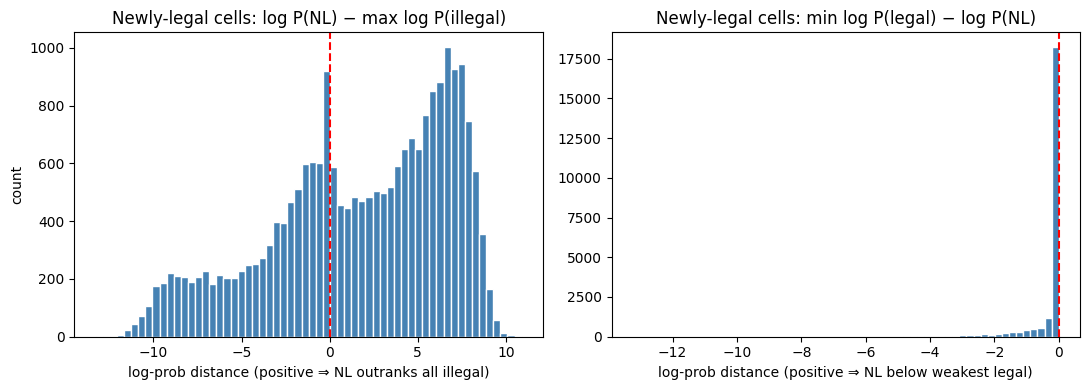

Newly-legal cells inspected: 22805
  Fraction above max-illegal: 62.98%
  Fraction below min-legal (Nanda's strict): 32.89%
  (dropped 0 +/-inf in 'above', 1 in 'below' — softmax rounded probability to 0 for these cells)


In [9]:
# Cell 11 — distance distributions for newly-legal cells
nl_above_max_illegal = []
nl_below_min_legal = []
for _, _, _, rec in records:
    intv_last = rec.extras['_intv_last']
    newly_legal_cells = sorted(set(rec.legal_cf) - set(rec.legal_orig))
    if not newly_legal_cells:
        continue
    nl_above_max_illegal.extend(
        metrics.logprob_distance_above_max_illegal(intv_last, newly_legal_cells, rec.legal_cf))
    nl_below_min_legal.extend(
        metrics.logprob_distance_below_min_legal(intv_last, newly_legal_cells, rec.legal_cf))

def _finite(xs):
    """Drop +/- inf values for plotting and report how many were dropped."""
    n_inf = sum(1 for v in xs if not np.isfinite(v))
    return [v for v in xs if np.isfinite(v)], n_inf

nl_above_finite, n_inf_above = _finite(nl_above_max_illegal)
nl_below_finite, n_inf_below = _finite(nl_below_min_legal)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].hist(nl_above_finite, bins=60, color='steelblue', edgecolor='white')
axs[0].axvline(0, color='red', linestyle='--')
axs[0].set_title('Newly-legal cells: log P(NL) − max log P(illegal)')
axs[0].set_xlabel('log-prob distance (positive ⇒ NL outranks all illegal)')
axs[0].set_ylabel('count')

axs[1].hist(nl_below_finite, bins=60, color='steelblue', edgecolor='white')
axs[1].axvline(0, color='red', linestyle='--')
axs[1].set_title('Newly-legal cells: min log P(legal) − log P(NL)')
axs[1].set_xlabel('log-prob distance (positive ⇒ NL below weakest legal)')
plt.tight_layout()
plt.savefig(iox.output_path('problem1_newly_legal_logprob_distance.png'), dpi=120)
plt.show()
print(f"Newly-legal cells inspected: {len(nl_above_max_illegal)}")
print(f"  Fraction above max-illegal: "
      f"{np.mean([v > 0 for v in nl_above_finite]):.2%}")
print(f"  Fraction below min-legal (Nanda's strict): "
      f"{np.mean([v < 0 for v in nl_below_finite]):.2%}")
if n_inf_above or n_inf_below:
    print(f"  (dropped {n_inf_above} +/-inf in 'above', {n_inf_below} in 'below' "
          f"— softmax rounded probability to 0 for these cells)")

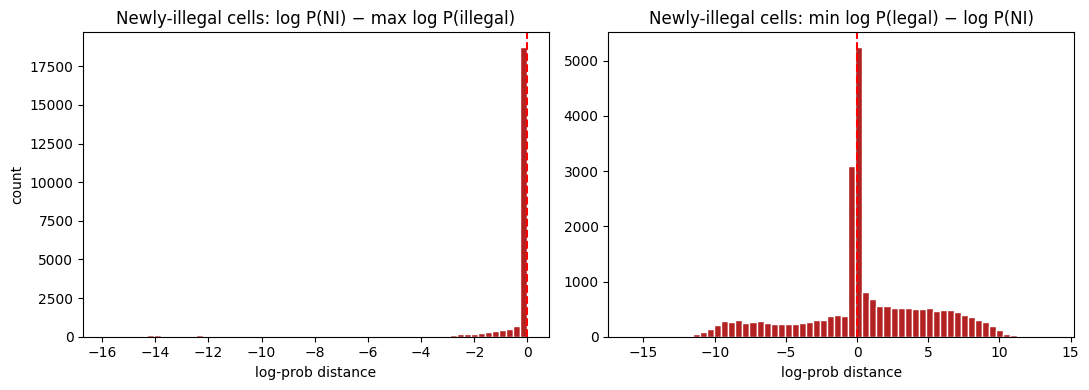

Newly-illegal cells inspected: 23278
  Fraction below min-legal (correctly suppressed): 47.60%
  (dropped 0 +/-inf in 'above', 13 in 'below')


In [11]:
# Cell 12 — distance distributions for newly-illegal cells
ni_above_max_illegal = []
ni_below_min_legal = []
for _, _, _, rec in records:
    intv_last = rec.extras['_intv_last']
    newly_illegal_cells = sorted(set(rec.legal_orig) - set(rec.legal_cf))
    if not newly_illegal_cells:
        continue
    ni_above_max_illegal.extend(
        metrics.logprob_distance_above_max_illegal(intv_last, newly_illegal_cells, rec.legal_cf))
    ni_below_min_legal.extend(
        metrics.logprob_distance_below_min_legal(intv_last, newly_illegal_cells, rec.legal_cf))

ni_above_finite, n_inf_above = _finite(ni_above_max_illegal)
ni_below_finite, n_inf_below = _finite(ni_below_min_legal)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].hist(ni_above_finite, bins=60, color='firebrick', edgecolor='white')
axs[0].axvline(0, color='red', linestyle='--')
axs[0].set_title('Newly-illegal cells: log P(NI) − max log P(illegal)')
axs[0].set_xlabel('log-prob distance')
axs[0].set_ylabel('count')

axs[1].hist(ni_below_finite, bins=60, color='firebrick', edgecolor='white')
axs[1].axvline(0, color='red', linestyle='--')
axs[1].set_title('Newly-illegal cells: min log P(legal) − log P(NI)')
axs[1].set_xlabel('log-prob distance')
plt.tight_layout()
plt.savefig(iox.output_path('problem1_newly_illegal_logprob_distance.png'), dpi=120)
plt.show()
print(f"Newly-illegal cells inspected: {len(ni_above_max_illegal)}")
print(f"  Fraction below min-legal (correctly suppressed): "
      f"{np.mean([v > 0 for v in ni_below_finite]):.2%}")
if n_inf_above or n_inf_below:
    print(f"  (dropped {n_inf_above} +/-inf in 'above', {n_inf_below} in 'below')")

### Mass-shift metrics

These six metrics together capture what fraction of probability mass the
intervention pushed in the correct direction:

| metric | meaning |
|---|---|
| `ΔP(legal_cf)` | total probability mass shifted onto counterfactual-legal cells |
| `P_before(NL)` | baseline mass on newly-legal cells (a useful denominator) |
| `ΔP(NL)` | probability added to newly-legal cells |
| `ΔP(NI)` | probability change on newly-illegal cells (negative = correctly suppressed) |
| `P_after(NI)` | residual mass on newly-illegal cells |
| `redistribution` | `min(ΔP(NL), −ΔP(NI))` — the weaker arm of "moved mass correctly" |

Compared to the binary "did NL enter top-K?" of top-N, this tells us how
*much* the model actually changed its beliefs.

In [12]:
# Cell 13 — mass-shift metrics aggregate
all_m = {k: [] for k in [
    'abs_dP_legal', 'P_before_newly_legal', 'abs_dP_newly_legal',
    'abs_dP_newly_illegal', 'P_after_newly_illegal', 'redistribution'
]}
for _, _, _, rec in records:
    intv_last = rec.extras['_intv_last']
    m = metrics.mass_shift_metrics(
        rec.extras['clean_logits_last'], intv_last, rec.legal_orig, rec.legal_cf)
    for k in all_m:
        all_m[k].append(m[k])

rows = [['metric', 'mean', 'std']]
for k, vals in all_m.items():
    mu, sd = metrics.mean_std(vals)
    rows.append([k, mu, sd])
iox.save_table(
    rows, filename='problem1_mass_shift_aggregate.txt',
    title=f'Mass-shift metrics aggregate (n={len(records)}, '
          f'cal_depth={params["cal_depth"]}, alpha={params["alpha"]})',
)

Mass-shift metrics aggregate (n=29235, cal_depth=0, alpha=2.0)

| metric                |    mean |    std |
|-----------------------|---------|--------|
| abs_dP_legal          |  0.0191 | 0.1319 |
| P_before_newly_legal  |  0.0002 | 0.0039 |
| abs_dP_newly_legal    |  0.0245 | 0.0549 |
| abs_dP_newly_illegal  | -0.0399 | 0.0602 |
| P_after_newly_illegal |  0.0396 | 0.0686 |
| redistribution        |  0.0074 | 0.0272 |

(saved to /Users/jmorriso/Git/othello_world/Intervention Results/problem1_mass_shift_aggregate.txt)


'Mass-shift metrics aggregate (n=29235, cal_depth=0, alpha=2.0)\n==============================================================\n\n| metric                |    mean |    std |\n|-----------------------|---------|--------|\n| abs_dP_legal          |  0.0191 | 0.1319 |\n| P_before_newly_legal  |  0.0002 | 0.0039 |\n| abs_dP_newly_legal    |  0.0245 | 0.0549 |\n| abs_dP_newly_illegal  | -0.0399 | 0.0602 |\n| P_after_newly_illegal |  0.0396 | 0.0686 |\n| redistribution        |  0.0074 | 0.0272 |\n'

## Section: Problem 2 — Top-N doesn't separate conditions

The same metrics, but now broken down by all 12 conditions × 3 squares = 36
cells. This reveals that interventions of different types are *expected* to
produce very different outcomes — and that averaging over them (as top-N
does) hides the actual phenomenology.

In [13]:
# Cell 14 — per-condition breakdown
import collections
buckets = collections.defaultdict(list)

for sq, cat, sub, rec in records:
    intv_last = rec.extras['_intv_last']
    m = metrics.mass_shift_metrics(
        rec.extras['clean_logits_last'], intv_last, rec.legal_orig, rec.legal_cf)
    li_b = metrics.li_topn_accuracy(rec.extras['clean_logits_last'], rec.legal_cf)
    li_a = metrics.li_topn_accuracy(intv_last, rec.legal_cf)
    li_shift = li_a - li_b if (li_a is not None and li_b is not None) else None
    buckets[(sq, cat, sub)].append({
        'li_shift': li_shift, **m,
    })

# Table: rows = (square, category, sub) sorted; cols = aggregated metrics.
rows = [['square', 'category', 'sub_condition', 'n',
         'li_shift', 'abs_dP_legal', 'abs_dP_NL', 'abs_dP_NI',
         'P_before_NL', 'P_after_NI', 'redistribution']]
metric_keys = ['li_shift', 'abs_dP_legal', 'abs_dP_newly_legal',
               'abs_dP_newly_illegal', 'P_before_newly_legal',
               'P_after_newly_illegal', 'redistribution']
for (sq, cat, sub), items in sorted(buckets.items()):
    row = [sq, cat, sub, len(items)]
    for k in metric_keys:
        vals = [d[k] for d in items if d[k] is not None]
        if vals:
            row.append(np.mean(vals))
        else:
            row.append(float('nan'))
    rows.append(row)

iox.save_table(
    rows, filename='problem2_per_condition_metrics.txt',
    title=f'Per-condition metrics (cal_depth={params["cal_depth"]}, '
          f'alpha={params["alpha"]}, mode={params["calibration_mode"]})',
)

Per-condition metrics (cal_depth=0, alpha=2.0, mode=fixed)

| square   | category   | sub_condition   |    n |   li_shift |   abs_dP_legal |   abs_dP_NL |   abs_dP_NI |   P_before_NL |   P_after_NI |   redistribution |
|----------|------------|-----------------|------|------------|----------------|-------------|-------------|---------------|--------------|------------------|
| (0,3)    | add_mine   | both            | 1000 |     0.0424 |         0.0741 |      0.0059 |     -0.0742 |        0.0006 |       0.0184 |           0.0058 |
| (0,3)    | add_mine   | newly_illegal   | 1000 |     0.0577 |         0.0631 |      0.0000 |     -0.0632 |        0.0000 |       0.0254 |           0.0000 |
| (0,3)    | add_mine   | newly_legal     | 1000 |     0.0796 |         0.0001 |      0.0148 |      0.0000 |        0.0000 |       0.0000 |           0.0000 |
| (0,3)    | add_yours  | both            | 1000 |     0.0056 |         0.0434 |      0.0008 |     -0.0434 |        0.0006 |       0.0551 |      

'Per-condition metrics (cal_depth=0, alpha=2.0, mode=fixed)\n==========================================================\n\n| square   | category   | sub_condition   |    n |   li_shift |   abs_dP_legal |   abs_dP_NL |   abs_dP_NI |   P_before_NL |   P_after_NI |   redistribution |\n|----------|------------|-----------------|------|------------|----------------|-------------|-------------|---------------|--------------|------------------|\n| (0,3)    | add_mine   | both            | 1000 |     0.0424 |         0.0741 |      0.0059 |     -0.0742 |        0.0006 |       0.0184 |           0.0058 |\n| (0,3)    | add_mine   | newly_illegal   | 1000 |     0.0577 |         0.0631 |      0.0000 |     -0.0632 |        0.0000 |       0.0254 |           0.0000 |\n| (0,3)    | add_mine   | newly_legal     | 1000 |     0.0796 |         0.0001 |      0.0148 |      0.0000 |        0.0000 |       0.0000 |           0.0000 |\n| (0,3)    | add_yours  | both            | 1000 |     0.0056 |         0.043

## Section: Problem 3 — Top-N ignores interference

Every intervention also perturbs probe predictions on *other* cells —
"crosstalk." This section quantifies it three ways:

1. **Mean count of cells whose probe argmax flipped** as a function of alpha,
   per target square, per condition.
2. **% of positions** where at least one *other* cell's probe argmax flipped.
3. **Cosine similarity tables** between probe directions at the target square
   and every other square — once for the *empty* direction, once for the
   *flip* direction. This is the geometric explanation for why crosstalk is
   high on certain squares.

To keep runtime reasonable, **the alpha sweep uses only 200 positions per
condition** (subsampled from the database).

In [14]:
# Cell 15 — alpha sweep crosstalk count per square per condition
ALPHA_GRID = [0, 0.5, 1, 1.5, 2, 2.5, 3]  # safer range; user-tunable
SUBSAMPLE_N = 200

# For each condition, build a 12-tables structure: one table per condition,
# rows = alpha, cols = squares.
import random
rng_sub = random.Random(params['seed'])

# Subsample once per (square, cat, sub) bucket.
subsamples = {}
for sq in db:
    for cat in db[sq]:
        for sub in db[sq][cat]:
            recs = db[sq][cat][sub]
            if len(recs) > SUBSAMPLE_N:
                subsamples[(sq, cat, sub)] = rng_sub.sample(recs, SUBSAMPLE_N)
            else:
                subsamples[(sq, cat, sub)] = recs

probe_full_mode = probe[params['probe_mode']]

# crosstalk_counts[(cat,sub)][alpha][sq_label] -> list of per-position counts
crosstalk_counts = {}
print(f"Alpha sweep at intervention_layer={params['intervention_layer']}, "
      f"probe_layer={params['probe_layer']} (cd={params['cal_depth']})")

for cat in config.CATEGORIES:
    for sub in config.SUB_CONDITIONS:
        crosstalk_counts[(cat, sub)] = {a: {f'({r},{c})': [] for (r, c) in squares}
                                         for a in ALPHA_GRID}
        for sq in db:
            recs = subsamples[(sq, cat, sub)]
            if not recs:
                continue
            for rec in recs:
                spec = rec.extras['spec']
                prefix = rec.extras['prefix_acts']
                target_cell = rec.square[0] * 8 + rec.square[1]
                clean_resid = rec.extras['clean_resid_at_probe']
                for a in ALPHA_GRID:
                    if a == 0:
                        crosstalk_counts[(cat, sub)][a][sq].append(0)
                        continue
                    intv_logits, intv_resid = intervention.run_with_intervention(
                        model, prefix, rec.position, [spec], [a],
                        intervene_layer=params['intervention_layer'],
                        capture_layer=params['probe_layer'],
                    )
                    n = metrics.crosstalk_count(
                        clean_resid, intv_resid, probe_full_mode,
                        rec.position, [target_cell],
                    )
                    crosstalk_counts[(cat, sub)][a][sq].append(n)
        print(f"  done {cat} | {sub}")

# Render one table per condition.
for cat in config.CATEGORIES:
    for sub in config.SUB_CONDITIONS:
        rows = [['alpha'] + [f'{sq} ({label})' for sq, label in zip(
            [f'({r},{c})' for (r,c) in squares],
            ['center' if (r,c)==(3,3) else 'edge' if (r,c)==(0,3) else 'intermediate'
             for (r,c) in squares])]]
        for a in ALPHA_GRID:
            row = [a]
            for sq in [f'({r},{c})' for (r,c) in squares]:
                vals = crosstalk_counts[(cat, sub)][a][sq]
                if vals:
                    mu, sd = metrics.mean_std(vals)
                    row.append(iox.fmt_mean_std(mu, sd))
                else:
                    row.append('—')
            rows.append(row)
        iox.save_table(
            rows,
            filename=f'problem3_crosstalk_alpha_sweep__{cat}__{sub}.txt',
            title=f'Crosstalk count (mean ± std), {cat} | {sub} '
                  f'(intervention at L{params["intervention_layer"]}, '
                  f'decode at L{params["probe_layer"]}, n≤{SUBSAMPLE_N})',
            print_too=True,
        )
print('All 12 condition-specific crosstalk tables saved.')

Alpha sweep at intervention_layer=4, probe_layer=4 (cd=0)
  done remove | newly_legal
  done remove | newly_illegal
  done remove | both
  done add_mine | newly_legal
  done add_mine | newly_illegal
  done add_mine | both
  done add_yours | newly_legal
  done add_yours | newly_illegal
  done add_yours | both
  done flip | newly_legal
  done flip | newly_illegal
  done flip | both
Crosstalk count (mean ± std), remove | newly_legal (intervention at L4, decode at L4, n≤200)

|   alpha | (3,3) (center)   | (0,3) (edge)   | (2,3) (intermediate)   |
|---------|------------------|----------------|------------------------|
|  0.0000 | 0.00 ± 0.00      | 0.00 ± 0.00    | 0.00 ± 0.00            |
|  0.5000 | 0.37 ± 0.64      | 0.07 ± 0.26    | 0.07 ± 0.29            |
|  1.0000 | 0.80 ± 0.98      | 0.16 ± 0.42    | 0.17 ± 0.43            |
|  1.5000 | 1.42 ± 1.29      | 0.20 ± 0.48    | 0.27 ± 0.53            |
|  2.0000 | 2.54 ± 1.81      | 0.26 ± 0.56    | 0.34 ± 0.61            |
|  2.5000 | 

In [13]:
# Cell 15b — alpha sweep crosstalk count per square (uniform random sample per square)
ALPHA_GRID = [0, 0.5, 1, 2, 3, 4, 5, 8]
N_PER_SQUARE = 1000

import random
rng_sub = random.Random(params['seed'])

# Derive (r, c) tuples from the database keys, e.g. '(3,3)' -> (3, 3).
def _parse_sq_label(s):
    inner = s.strip('()').split(',')
    return (int(inner[0]), int(inner[1]))

squares = [_parse_sq_label(s) for s in db]
print(f"Squares in db: {squares}")

# Pool ALL records per square (across all conditions), then take a single
# uniform random sample of size N_PER_SQUARE per square.
records_by_square = {f'({r},{c})': [] for (r, c) in squares}
for sq in db:
    for cat in db[sq]:
        for sub in db[sq][cat]:
            records_by_square[sq].extend(db[sq][cat][sub])

for sq, recs in records_by_square.items():
    if len(recs) > N_PER_SQUARE:
        records_by_square[sq] = rng_sub.sample(recs, N_PER_SQUARE)

probe_full_mode = probe[params['probe_mode']]

crosstalk_by_square = {a: {sq: [] for sq in records_by_square} for a in ALPHA_GRID}

print(f"Alpha sweep at intervention_layer={params['intervention_layer']}, "
      f"probe_layer={params['probe_layer']} (cd={params['cal_depth']})")
print(f"Uniform random sample per square: " +
      ", ".join(f'{sq}: {len(rs)}' for sq, rs in records_by_square.items()))

from tqdm.auto import tqdm
total = sum(len(rs) for rs in records_by_square.values())
pbar = tqdm(total=total, desc='records')

for sq, recs in records_by_square.items():
    for rec in recs:
        spec = rec.extras['spec']
        prefix = rec.extras['prefix_acts']
        target_cell = rec.square[0] * 8 + rec.square[1]
        clean_resid = rec.extras['clean_resid_at_probe']
        for a in ALPHA_GRID:
            if a == 0:
                crosstalk_by_square[a][sq].append(0)
                continue
            intv_logits, intv_resid = intervention.run_with_intervention(
                model, prefix, rec.position, [spec], [a],
                intervene_layer=params['intervention_layer'],
                capture_layer=params['probe_layer'],
            )
            n = metrics.crosstalk_count(
                clean_resid, intv_resid, probe_full_mode,
                rec.position, [target_cell],
            )
            crosstalk_by_square[a][sq].append(n)
        pbar.update(1)
pbar.close()

sq_labels = [f'({r},{c})' for (r, c) in squares]
sq_descs = ['center' if (r,c)==(3,3) else 'edge' if (r,c)==(0,3) else 'intermediate'
            for (r, c) in squares]
rows = [['alpha'] + [f'{sq} ({desc})' for sq, desc in zip(sq_labels, sq_descs)]]
for a in ALPHA_GRID:
    row = [a]
    for sq in sq_labels:
        vals = crosstalk_by_square[a][sq]
        if vals:
            mu, sd = metrics.mean_std(vals)
            row.append(iox.fmt_mean_std(mu, sd))
        else:
            row.append('—')
    rows.append(row)
iox.save_table(
    rows,
    filename='problem3_crosstalk_alpha_sweep__uniform_per_square.txt',
    title=f'Crosstalk count (mean ± std), uniform random sample of {N_PER_SQUARE} '
          f'positions per square (intervention at L{params["intervention_layer"]}, '
          f'decode at L{params["probe_layer"]})',
)



Squares in db: [(3, 3), (0, 3), (2, 3)]
Alpha sweep at intervention_layer=4, probe_layer=4 (cd=0)
Uniform random sample per square: (3,3): 1000, (0,3): 1000, (2,3): 1000


records: 100%|██████████| 3000/3000 [03:18<00:00, 15.12it/s]

Crosstalk count (mean ± std), uniform random sample of 1000 positions per square (intervention at L4, decode at L4)

|   alpha | (3,3) (center)   | (0,3) (edge)   | (2,3) (intermediate)   |
|---------|------------------|----------------|------------------------|
|  0.0000 | 0.00 ± 0.00      | 0.00 ± 0.00    | 0.00 ± 0.00            |
|  0.5000 | 0.21 ± 0.47      | 0.06 ± 0.24    | 0.09 ± 0.32            |
|  1.0000 | 0.51 ± 0.83      | 0.12 ± 0.34    | 0.19 ± 0.47            |
|  2.0000 | 1.78 ± 2.16      | 0.29 ± 0.56    | 0.38 ± 0.72            |
|  3.0000 | 4.30 ± 4.85      | 0.56 ± 0.82    | 0.71 ± 1.05            |
|  4.0000 | 6.80 ± 7.33      | 0.95 ± 1.04    | 1.12 ± 1.40            |
|  5.0000 | 8.99 ± 9.37      | 1.47 ± 1.24    | 1.63 ± 1.82            |
|  8.0000 | 14.04 ± 13.33    | 3.04 ± 1.93    | 3.84 ± 2.86            |

(saved to /Users/jmorriso/Git/othello_world/Intervention Results/problem3_crosstalk_alpha_sweep__uniform_per_square.txt)


'Crosstalk count (mean ± std), uniform random sample of 1000 positions per square (intervention at L4, decode at L4)\n===================================================================================================================\n\n|   alpha | (3,3) (center)   | (0,3) (edge)   | (2,3) (intermediate)   |\n|---------|------------------|----------------|------------------------|\n|  0.0000 | 0.00 ± 0.00      | 0.00 ± 0.00    | 0.00 ± 0.00            |\n|  0.5000 | 0.21 ± 0.47      | 0.06 ± 0.24    | 0.09 ± 0.32            |\n|  1.0000 | 0.51 ± 0.83      | 0.12 ± 0.34    | 0.19 ± 0.47            |\n|  2.0000 | 1.78 ± 2.16      | 0.29 ± 0.56    | 0.38 ± 0.72            |\n|  3.0000 | 4.30 ± 4.85      | 0.56 ± 0.82    | 0.71 ± 1.05            |\n|  4.0000 | 6.80 ± 7.33      | 0.95 ± 1.04    | 1.12 ± 1.40            |\n|  5.0000 | 8.99 ± 9.37      | 1.47 ± 1.24    | 1.63 ± 1.82            |\n|  8.0000 | 14.04 ± 13.33    | 3.04 ± 1.93    | 3.84 ± 2.86            |\n'

In [15]:
# Cell 16 — % positions where at least one OTHER cell's argmax flipped
for cat in config.CATEGORIES:
    for sub in config.SUB_CONDITIONS:
        rows = [['alpha'] + [f'{sq}' for sq in [f'({r},{c})' for (r,c) in squares]]]
        for a in ALPHA_GRID:
            row = [a]
            for sq in [f'({r},{c})' for (r,c) in squares]:
                vals = crosstalk_counts[(cat, sub)][a][sq]
                if vals:
                    pct = 100 * np.mean([v > 0 for v in vals])
                    row.append(f'{pct:.1f}%')
                else:
                    row.append('—')
            rows.append(row)
        iox.save_table(
            rows,
            filename=f'problem3_any_other_flipped__{cat}__{sub}.txt',
            title=f'% positions where ≥1 other cell flipped, {cat} | {sub}',
            print_too=True,
        )
print('All 12 "any flipped" tables saved.')

% positions where ≥1 other cell flipped, remove | newly_legal

|   alpha | (3,3)   | (0,3)   | (2,3)   |
|---------|---------|---------|---------|
|  0.0000 | 0.0%    | 0.0%    | 0.0%    |
|  0.5000 | 28.5%   | 7.0%    | 6.0%    |
|  1.0000 | 50.5%   | 14.0%   | 14.0%   |
|  1.5000 | 72.0%   | 16.5%   | 22.5%   |
|  2.0000 | 88.0%   | 20.0%   | 27.5%   |
|  2.5000 | 94.5%   | 26.0%   | 35.0%   |
|  3.0000 | 97.5%   | 36.0%   | 44.5%   |

(saved to /Users/jmorriso/Git/othello_world/Intervention Results/problem3_any_other_flipped__remove__newly_legal.txt)
% positions where ≥1 other cell flipped, remove | newly_illegal

|   alpha | (3,3)   | (0,3)   | (2,3)   |
|---------|---------|---------|---------|
|  0.0000 | 0.0%    | 0.0%    | 0.0%    |
|  0.5000 | 27.5%   | 11.5%   | 3.5%    |
|  1.0000 | 50.0%   | 21.0%   | 7.5%    |
|  1.5000 | 81.5%   | 30.0%   | 10.5%   |
|  2.0000 | 95.0%   | 38.0%   | 13.5%   |
|  2.5000 | 99.0%   | 41.5%   | 18.0%   |
|  3.0000 | 99.0%   | 46.0%   | 22.0%  

In [14]:
# Cell 16b — % positions where ≥1 other cell's argmax flipped (averaged across conditions)
# Uses crosstalk_by_square from the modified Cell 15.

sq_labels = [f'({r},{c})' for (r, c) in squares]
sq_descs = ['center' if (r,c)==(3,3) else 'edge' if (r,c)==(0,3) else 'intermediate'
            for (r, c) in squares]

rows = [['alpha'] + [f'{sq} ({desc})' for sq, desc in zip(sq_labels, sq_descs)]]
for a in ALPHA_GRID:
    row = [a]
    for sq in sq_labels:
        vals = crosstalk_by_square[a][sq]
        if vals:
            pct = 100 * np.mean([v > 0 for v in vals])
            row.append(f'{pct:.1f}%')
        else:
            row.append('—')
    rows.append(row)

iox.save_table(
    rows,
    filename='problem3_any_other_flipped__uniform_per_square.txt',
    title=f'% positions where ≥1 other cell flipped, uniform random sample per square '
          f'(intervention at L{params["intervention_layer"]}, '
          f'decode at L{params["probe_layer"]})',
)


% positions where ≥1 other cell flipped, uniform random sample per square (intervention at L4, decode at L4)

|   alpha | (3,3) (center)   | (0,3) (edge)   | (2,3) (intermediate)   |
|---------|------------------|----------------|------------------------|
|  0.0000 | 0.0%             | 0.0%           | 0.0%                   |
|  0.5000 | 18.6%            | 6.0%           | 7.9%                   |
|  1.0000 | 34.7%            | 12.0%          | 15.8%                  |
|  2.0000 | 58.5%            | 24.0%          | 27.1%                  |
|  3.0000 | 65.3%            | 39.8%          | 41.7%                  |
|  4.0000 | 71.0%            | 58.2%          | 52.4%                  |
|  5.0000 | 75.8%            | 75.0%          | 62.2%                  |
|  8.0000 | 88.3%            | 90.2%          | 88.2%                  |

(saved to /Users/jmorriso/Git/othello_world/Intervention Results/problem3_any_other_flipped__uniform_per_square.txt)


'% positions where ≥1 other cell flipped, uniform random sample per square (intervention at L4, decode at L4)\n============================================================================================================\n\n|   alpha | (3,3) (center)   | (0,3) (edge)   | (2,3) (intermediate)   |\n|---------|------------------|----------------|------------------------|\n|  0.0000 | 0.0%             | 0.0%           | 0.0%                   |\n|  0.5000 | 18.6%            | 6.0%           | 7.9%                   |\n|  1.0000 | 34.7%            | 12.0%          | 15.8%                  |\n|  2.0000 | 58.5%            | 24.0%          | 27.1%                  |\n|  3.0000 | 65.3%            | 39.8%          | 41.7%                  |\n|  4.0000 | 71.0%            | 58.2%          | 52.4%                  |\n|  5.0000 | 75.8%            | 75.0%          | 62.2%                  |\n|  8.0000 | 88.3%            | 90.2%          | 88.2%                  |\n'

In [16]:
# Cell 17 — cosine similarity tables for empty direction
def cosine_table_for_target(probe_tensor, target_r, target_c, probe_mode, kind):
    # Build all 64 cells' directions
    if kind == 'empty':
        dirs = {}
        for r in range(8):
            for c in range(8):
                d = probes.empty_direction(probe_tensor, r, c, probe_mode=probe_mode)
                dirs[(r, c)] = probes.normalize(d).cpu().numpy()
    elif kind == 'flip':
        dirs = {}
        for r in range(8):
            for c in range(8):
                d = probes.flip_direction(probe_tensor, r, c, probe_mode=probe_mode)
                dirs[(r, c)] = probes.normalize(d).cpu().numpy()
    else:
        raise ValueError(kind)
    target_d = dirs[(target_r, target_c)]
    grid = np.zeros((8, 8))
    for r in range(8):
        for c in range(8):
            grid[r, c] = abs(np.dot(target_d, dirs[(r, c)]))
    return grid

CENTER_FLAT = config.CENTER_CELLS
for (tr, tc) in squares:
    grid = cosine_table_for_target(probe.cpu(), tr, tc, params['probe_mode'], 'empty')
    header = ['row'] + [str(c) for c in range(8)]
    rows = [header]
    for r in range(8):
        row = [str(r)]
        for c in range(8):
            tag = 'T' if (r, c) == (tr, tc) else ('*' if (r*8+c) in CENTER_FLAT else ' ')
            row.append(f'{grid[r, c]:.3f}{tag}')
        rows.append(row)
    iox.save_table(
        rows,
        filename=f'problem3_cosine_empty__target_{tr}_{tc}.txt',
        title=f'|cos| of empty direction with target ({tr},{tc}) '
              f'(T=target, *=board-center starting cell, mode={params["probe_mode"]})',
        print_too=True,
    )
print('Cosine (empty) tables saved.')

|cos| of empty direction with target (3,3) (T=target, *=board-center starting cell, mode=0)

|   row |      0 |      1 |      2 | 3      | 4      |      5 |      6 |      7 |
|-------|--------|--------|--------|--------|--------|--------|--------|--------|
|     0 | 0.1530 | 0.0880 | 0.0510 | 0.044  | 0.046  | 0.0810 | 0.1120 | 0.1670 |
|     1 | 0.1230 | 0.0110 | 0.0450 | 0.072  | 0.060  | 0.0290 | 0.0100 | 0.1450 |
|     2 | 0.0700 | 0.0460 | 0.1170 | 0.134  | 0.128  | 0.1110 | 0.0210 | 0.0790 |
|     3 | 0.0300 | 0.0580 | 0.1690 | 1.000T | 0.953* | 0.1300 | 0.0450 | 0.0490 |
|     4 | 0.0390 | 0.0520 | 0.1460 | 0.953* | 0.957* | 0.1330 | 0.0500 | 0.0680 |
|     5 | 0.0780 | 0.0630 | 0.0750 | 0.115  | 0.129  | 0.1390 | 0.0400 | 0.0790 |
|     6 | 0.0930 | 0.0180 | 0.0360 | 0.056  | 0.064  | 0.0270 | 0.0170 | 0.1390 |
|     7 | 0.1540 | 0.1200 | 0.0740 | 0.075  | 0.053  | 0.1060 | 0.1190 | 0.1480 |

(saved to /Users/jmorriso/Git/othello_world/Intervention Results/problem3_cosine_empty

In [17]:
# Cell 18 — cosine similarity tables for flip direction
for (tr, tc) in squares:
    grid = cosine_table_for_target(probe.cpu(), tr, tc, params['probe_mode'], 'flip')
    header = ['row'] + [str(c) for c in range(8)]
    rows = [header]
    for r in range(8):
        row = [str(r)]
        for c in range(8):
            tag = 'T' if (r, c) == (tr, tc) else ('*' if (r*8+c) in CENTER_FLAT else ' ')
            row.append(f'{grid[r, c]:.3f}{tag}')
        rows.append(row)
    iox.save_table(
        rows,
        filename=f'problem3_cosine_flip__target_{tr}_{tc}.txt',
        title=f'|cos| of flip (mine-yours) direction with target ({tr},{tc})',
        print_too=True,
    )
print('Cosine (flip) tables saved.')

|cos| of flip (mine-yours) direction with target (3,3)

|   row |      0 |      1 |      2 | 3      | 4      |      5 |      6 |      7 |
|-------|--------|--------|--------|--------|--------|--------|--------|--------|
|     0 | 0.0420 | 0.0130 | 0.0370 | 0.008  | 0.021  | 0.0080 | 0.0140 | 0.0100 |
|     1 | 0.0150 | 0.0900 | 0.0210 | 0.027  | 0.027  | 0.0630 | 0.0220 | 0.0260 |
|     2 | 0.0300 | 0.0380 | 0.1410 | 0.078  | 0.097  | 0.0160 | 0.0120 | 0.0200 |
|     3 | 0.0070 | 0.0420 | 0.0960 | 1.000T | 0.079* | 0.0270 | 0.0090 | 0.0170 |
|     4 | 0.0370 | 0.0330 | 0.1100 | 0.081* | 0.103* | 0.0000 | 0.0200 | 0.0170 |
|     5 | 0.0230 | 0.0620 | 0.0070 | 0.055  | 0.016  | 0.0930 | 0.0030 | 0.0330 |
|     6 | 0.0210 | 0.0000 | 0.0000 | 0.027  | 0.012  | 0.0120 | 0.0820 | 0.0010 |
|     7 | 0.0020 | 0.0140 | 0.0050 | 0.008  | 0.024  | 0.0010 | 0.0050 | 0.0060 |

(saved to /Users/jmorriso/Git/othello_world/Intervention Results/problem3_cosine_flip__target_3_3.txt)
|cos| of flip (mine-

In [18]:
# Cell 19 — entanglement by geometric relationship (row / col / diag / none)
def geometric_bin(target, other):
    tr, tc = target; r, c = other
    if (tr, tc) == (r, c):
        return None
    if tr == r:
        return 'same_row'
    if tc == c:
        return 'same_col'
    if abs(tr - r) == abs(tc - c):
        return 'same_diag'
    return 'none'

for kind in ('empty', 'flip'):
    rows = [['target', 'same_row', 'same_col', 'same_diag', 'none']]
    for (tr, tc) in squares:
        grid = cosine_table_for_target(probe.cpu(), tr, tc, params['probe_mode'], kind)
        bins = {'same_row': [], 'same_col': [], 'same_diag': [], 'none': []}
        for r in range(8):
            for c in range(8):
                if (r*8 + c) in CENTER_FLAT and (r, c) != (tr, tc):
                    continue   # exclude centers as 'other'
                b = geometric_bin((tr, tc), (r, c))
                if b is not None:
                    bins[b].append(grid[r, c])
        rows.append([f'({tr},{tc})'] +
                    [f'{np.mean(bins[b]):.3f}' if bins[b] else '—'
                     for b in ('same_row', 'same_col', 'same_diag', 'none')])
    iox.save_table(
        rows,
        filename=f'problem3_entanglement_by_geometry__{kind}.txt',
        title=f'Mean |cos| of {kind} direction by geometric relationship',
    )

Mean |cos| of empty direction by geometric relationship

| target   |   same_row |   same_col |   same_diag |   none |
|----------|------------|------------|-------------|--------|
| (3,3)    |     0.0800 |     0.0830 |      0.0960 | 0.0780 |
| (0,3)    |     0.0960 |     0.0510 |      0.0380 | 0.0110 |
| (2,3)    |     0.0420 |     0.0580 |      0.0580 | 0.0200 |

(saved to /Users/jmorriso/Git/othello_world/Intervention Results/problem3_entanglement_by_geometry__empty.txt)
Mean |cos| of flip direction by geometric relationship

| target   |   same_row |   same_col |   same_diag |   none |
|----------|------------|------------|-------------|--------|
| (3,3)    |     0.0330 |     0.0340 |      0.0680 | 0.0160 |
| (0,3)    |     0.1290 |     0.0370 |      0.0540 | 0.0090 |
| (2,3)    |     0.0600 |     0.0490 |      0.0690 | 0.0150 |

(saved to /Users/jmorriso/Git/othello_world/Intervention Results/problem3_entanglement_by_geometry__flip.txt)


## Section: Problem 4 — Top-N misses multi-cell interventions

Apply N ∈ {1, 2, 3, 8} *simultaneous* interventions of the **same**
(square, category, sub_condition) type. For each value of N and each
condition, we count how many database positions admit that many
non-interacting cells from the same condition, and compute all our metrics.

This tests whether the model's response to interventions scales correctly
when multiple cells are modified at once.

In [15]:
# Cell 20 — multi-cell interventions (subsampled for tractable runtime)
#
# For each (category, sub_condition) pool, find positions where we can apply
# N simultaneous interventions of the same condition type. The
# legal-moves-on-modified-board check is the expensive part, so we cap pool
# at POOL_SUBSAMPLE and hits at MAX_HITS to keep runtime ~5-10 min total
# instead of ~4 hours over the full database.
import itertools, collections, random as _r
from tqdm.auto import tqdm

N_VALUES = [1, 2, 3, 8]
POOL_SUBSAMPLE = 100
MAX_HITS = 50

def find_multi_cell_interventions(rec_pool, category, sub, n_target, max_tries=50):
    out = []
    for rec in rec_pool:
        if len(out) >= MAX_HITS:
            break
        board = rec.board_state
        next_color = rec.next_color
        legal_orig = set(rec.legal_orig)
        cands = []
        for r in range(8):
            for c in range(8):
                cell = r*8 + c
                if cell in config.CENTER_CELLS:
                    continue
                v = int(board[r, c])
                if not data.category_applicable(category, v):
                    continue
                tgt = data.target_val_for_category(category, v, next_color)
                mod = board.copy(); mod[r, c] = tgt
                lcf = data.legal_moves_on(mod, next_color)
                if data.classify_change(legal_orig, lcf) == sub:
                    cands.append((r, c, v, tgt))
        if len(cands) < n_target:
            continue
        rng = _r.Random(rec.position * 7919)
        for combo in itertools.islice(itertools.combinations(cands, n_target), max_tries):
            mod = board.copy()
            for (r, c, v, tgt) in combo:
                mod[r, c] = tgt
            lcf = data.legal_moves_on(mod, next_color)
            if data.classify_change(legal_orig, lcf) == sub:
                out.append((rec, list(combo), lcf))
                break
    return out

rows = [['category', 'sub', 'N', 'n_found', 'mean_li_shift',
         'mean_abs_dP_legal', 'mean_abs_dP_NL', 'mean_abs_dP_NI',
         'mean_redistribution']]
work = [(c, s, n) for c in config.CATEGORIES
                  for s in config.SUB_CONDITIONS
                  for n in N_VALUES]
rng_sub = _r.Random(params['seed'])

for cat, sub, N in tqdm(work, desc='multi-cell'):
    pool = []
    for sq in db:
        pool.extend(db[sq][cat][sub])
    if len(pool) > POOL_SUBSAMPLE:
        pool = rng_sub.sample(pool, POOL_SUBSAMPLE)
    hits = find_multi_cell_interventions(pool, cat, sub, N)
    if not hits:
        rows.append([cat, sub, N, 0, '—', '—', '—', '—', '—'])
        continue
    li_shifts, dpls, dpnls, dpnis, reds = [], [], [], [], []
    for rec, combo, lcf in hits:
        prefix = rec.extras['prefix_acts']
        pos = rec.position
        specs = []
        for (r, c, v, tgt) in combo:
            cur_cls = probes.board_val_to_probe_class(v, rec.next_color,
                                                      params['probe_mode'])
            tgt_cls = probes.board_val_to_probe_class(tgt, rec.next_color,
                                                      params['probe_mode'])
            spec = intervention.InterventionSpec.from_probe(
                probe, params['probe_mode'], r, c, cur_cls, tgt_cls,
                h_at_intervention=prefix[0, pos])
            specs.append(spec)
        alphas = [alpha_for(rec)] * len(specs)
        intv_logits, _ = intervention.run_with_intervention(
            model, prefix, pos, specs, alphas,
            intervene_layer=params['intervention_layer'])
        intv_last = intv_logits[0, -1].cpu()
        m = metrics.mass_shift_metrics(
            rec.extras['clean_logits_last'], intv_last,
            rec.legal_orig, sorted(lcf))
        li_b = metrics.li_topn_accuracy(rec.extras['clean_logits_last'], sorted(lcf))
        li_a = metrics.li_topn_accuracy(intv_last, sorted(lcf))
        if li_a is not None and li_b is not None:
            li_shifts.append(li_a - li_b)
        dpls.append(m['abs_dP_legal'])
        dpnls.append(m['abs_dP_newly_legal'])
        dpnis.append(m['abs_dP_newly_illegal'])
        reds.append(m['redistribution'])
    rows.append([cat, sub, N, len(hits),
                 f'{np.mean(li_shifts):+.4f}' if li_shifts else '—',
                 f'{np.mean(dpls):+.4f}',
                 f'{np.mean(dpnls):+.4f}',
                 f'{np.mean(dpnis):+.4f}',
                 f'{np.mean(reds):.4f}'])

iox.save_table(
    rows, filename='problem4_multi_cell_interventions.txt',
    title=f'Multi-cell interventions (cal_depth={params["cal_depth"]}, '
          f'alpha={params["alpha"]}, mode={params["calibration_mode"]}, '
          f'pool ≤{POOL_SUBSAMPLE}, ≤{MAX_HITS} hits/cond)',
)

multi-cell: 100%|██████████| 48/48 [00:27<00:00,  1.77it/s]

Multi-cell interventions (cal_depth=0, alpha=2.0, mode=fixed, pool ≤100, ≤50 hits/cond)

| category   | sub           |   N |   n_found |   mean_li_shift |   mean_abs_dP_legal |   mean_abs_dP_NL |   mean_abs_dP_NI |   mean_redistribution |
|------------|---------------|-----|-----------|-----------------|---------------------|------------------|------------------|-----------------------|
| remove     | newly_legal   |   1 |        50 |          0.0986 |              0.0002 |           0.0663 |           0.0000 |                0.0000 |
| remove     | newly_legal   |   2 |        50 |          0.1636 |              0.0013 |           0.1144 |           0.0000 |                0.0000 |
| remove     | newly_legal   |   3 |        50 |          0.2207 |             -0.0016 |           0.1363 |           0.0000 |                0.0000 |
| remove     | newly_legal   |   8 |        50 |          0.2813 |             -0.0219 |           0.2152 |           0.0000 |                0.0000 |
| rem

'Multi-cell interventions (cal_depth=0, alpha=2.0, mode=fixed, pool ≤100, ≤50 hits/cond)\n=======================================================================================\n\n| category   | sub           |   N |   n_found |   mean_li_shift |   mean_abs_dP_legal |   mean_abs_dP_NL |   mean_abs_dP_NI |   mean_redistribution |\n|------------|---------------|-----|-----------|-----------------|---------------------|------------------|------------------|-----------------------|\n| remove     | newly_legal   |   1 |        50 |          0.0986 |              0.0002 |           0.0663 |           0.0000 |                0.0000 |\n| remove     | newly_legal   |   2 |        50 |          0.1636 |              0.0013 |           0.1144 |           0.0000 |                0.0000 |\n| remove     | newly_legal   |   3 |        50 |          0.2207 |             -0.0016 |           0.1363 |           0.0000 |                0.0000 |\n| remove     | newly_legal   |   8 |        50 |          0

## Section: Interventions on the 1-layer MLP

We rerun the same analysis on the 1-layer pattern-detector MLPs (no
transformer blocks, no propagation depth choice to be made). The MLP takes
move-history features (180-d `wheneven` or 3600-d `move_grid`) and outputs
960 pattern logits; we aggregate these to 60 cell probabilities via
`prob_or` (noisy-or).

For interventions, we use a **Nanda-style probe trained on the MLP's hidden
state** (the published probes
`probe_direct_H512_wheneven.pt` and `probe_direct_H4096_move_grid.pt`) and
push the hidden along the corresponding mine–yours direction.

This serves as a control: do the problems-with-top-N we identified above
generalize to an architecture without depth?

The MLP intervention pipeline lives in `src/mlp.py`. It mirrors the OGPT
pipeline but operates on the 1-layer pattern detector's hidden layer.

**Checkpoint files** (not bundled with this repo; copy from cluster):

```
experiments/.../pattern_detector_checkpoints/
  pattern_simple_direct_H512_wheneven.pt
  probe_direct_H512_wheneven.pt
  pattern_simple_direct_H4096_move_grid.pt
  probe_direct_H4096_move_grid.pt
```

If any are missing, the cell below will report which and skip the run.

In [20]:
# Cell 21a — generic MLP intervention runner (reused for both H=512 and H=4096)
from src import mlp as srcmlp

def run_mlp_experiment(model_key: str, *, output_prefix: str, subsample_n: int = 200):
    """Run the same problem-1/2 measurements on an MLP model. Writes a single
    table summarizing Li-N, mass-shift metrics by condition."""
    ckpt_path = srcmlp.MLP_CKPT_PATHS[model_key]
    probe_path = srcmlp.MLP_PROBE_PATHS[model_key]
    if not (os.path.exists(ckpt_path) and os.path.exists(probe_path)):
        print(f"[{model_key}] checkpoint or probe missing — skipping.")
        print(f"  expected: {ckpt_path}")
        print(f"  expected: {probe_path}")
        return
    print(f"[{model_key}] loading MLP + probe...")
    bundle = srcmlp.load_mlp(ckpt_path, device=DEVICE)
    probe_bundle = srcmlp.load_mlp_probe(
        probe_path, hidden_dim=bundle['hidden_dim'], device=DEVICE)
    print(f"  hidden_dim={bundle['hidden_dim']}, "
          f"feature_type={bundle['feature_type']}")

    # Subsample the database for MLP runs (large H * 36k positions is heavy).
    import random as _r
    rng = _r.Random(params['seed'])
    sub_records = []
    for sq, cat, sub, rec in records:
        if rng.random() * 12 < 1:   # ~1/12 of positions
            sub_records.append((sq, cat, sub, rec))
        if len(sub_records) >= subsample_n:
            break
    if subsample_n is None or len(sub_records) > subsample_n:
        rng.shuffle(sub_records)
        sub_records = sub_records[:subsample_n]
    print(f"  running on {len(sub_records)} positions (subsampled)")

    # Cache clean MLP state for each
    from tqdm.auto import tqdm
    for _, _, _, rec in tqdm(sub_records, desc='MLP clean'):
        srcmlp.cache_mlp_clean_state(rec, bundle, probe_bundle, device=DEVICE)

    # Run interventions and collect per-condition metrics. MLP probabilities
    # are noisy-or aggregates (each in [0,1]) — we normalize to sum-to-1 so
    # the mass-shift semantics match OGPT's categorical-distribution case.
    import collections
    buckets = collections.defaultdict(list)
    for sq, cat, sub, rec in sub_records:
        spec = rec.extras['mlp_spec']
        cp_intv, _ = srcmlp.run_mlp_intervention(
            rec, bundle, probe_bundle, [spec], [params['alpha']], device=DEVICE)
        cp_clean = rec.extras['mlp_clean_probs']
        p_clean = srcmlp.normalize_probs(cp_clean).cpu()
        p_intv = srcmlp.normalize_probs(cp_intv).cpu()
        m = metrics.mass_shift_metrics_from_probs(
            p_clean, p_intv, rec.legal_orig, rec.legal_cf)
        li_b = srcmlp.li_topn_from_probs(p_clean, rec.legal_cf)
        li_a = srcmlp.li_topn_from_probs(p_intv, rec.legal_cf)
        li_shift = (li_a - li_b) if (li_a is not None and li_b is not None) else None
        buckets[(sq, cat, sub)].append({'li_shift': li_shift, **m})

    rows = [['square', 'category', 'sub', 'n', 'li_shift',
             'abs_dP_legal', 'abs_dP_NL', 'abs_dP_NI', 'redistribution']]
    keys = ['li_shift', 'abs_dP_legal', 'abs_dP_newly_legal',
            'abs_dP_newly_illegal', 'redistribution']
    for (sq, cat, sub), items in sorted(buckets.items()):
        row = [sq, cat, sub, len(items)]
        for k in keys:
            vals = [d[k] for d in items if d[k] is not None]
            row.append(np.mean(vals) if vals else float('nan'))
        rows.append(row)
    iox.save_table(
        rows, filename=f'{output_prefix}__metrics.txt',
        title=f'MLP {model_key} per-condition metrics '
              f'(alpha={params["alpha"]}, mode={params["calibration_mode"]})',
    )
print('Runner ready.')

Runner ready.


In [21]:
# Cell 21b — H=512 wheneven MLP
run_mlp_experiment('wheneven_H512', output_prefix='mlp_wheneven_H512')

[wheneven_H512] loading MLP + probe...
  hidden_dim=512, feature_type=when+even
  running on 200 positions (subsampled)


MLP clean: 100%|██████████| 200/200 [00:00<00:00, 1089.69it/s]


MLP wheneven_H512 per-condition metrics (alpha=2.0, mode=fixed)

| square   | category   | sub           |   n |   li_shift |   abs_dP_legal |   abs_dP_NL |   abs_dP_NI |   redistribution |
|----------|------------|---------------|-----|------------|----------------|-------------|-------------|------------------|
| (3,3)    | remove     | both          |  44 |    -0.4808 |        -0.4611 |      0.0000 |     -0.0716 |           0.0000 |
| (3,3)    | remove     | newly_illegal |  85 |    -0.4650 |        -0.4265 |      0.0000 |     -0.0719 |           0.0000 |
| (3,3)    | remove     | newly_legal   |  71 |    -0.5661 |        -0.5476 |      0.0000 |      0.0000 |           0.0000 |

(saved to /Users/jmorriso/Git/othello_world/Intervention Results/mlp_wheneven_H512__metrics.txt)


In [22]:
# Cell 22 — H=4096 movegrid MLP
run_mlp_experiment('movegrid_H4096', output_prefix='mlp_movegrid_H4096')

[movegrid_H4096] loading MLP + probe...
  hidden_dim=4096, feature_type=move_grid
  running on 200 positions (subsampled)


MLP clean: 100%|██████████| 200/200 [00:00<00:00, 794.87it/s]


MLP movegrid_H4096 per-condition metrics (alpha=2.0, mode=fixed)

| square   | category   | sub           |   n |   li_shift |   abs_dP_legal |   abs_dP_NL |   abs_dP_NI |   redistribution |
|----------|------------|---------------|-----|------------|----------------|-------------|-------------|------------------|
| (3,3)    | remove     | both          |  44 |    -0.5249 |        -0.4309 |      0.0000 |     -0.0560 |           0.0000 |
| (3,3)    | remove     | newly_illegal |  85 |    -0.5166 |        -0.3886 |      0.0000 |     -0.0734 |           0.0000 |
| (3,3)    | remove     | newly_legal   |  71 |    -0.6131 |        -0.5164 |      0.0000 |      0.0000 |           0.0000 |

(saved to /Users/jmorriso/Git/othello_world/Intervention Results/mlp_movegrid_H4096__metrics.txt)
